## **Predicting on single patient data from inferno model in R**

                                                                  IMGPATH
1050 /home/maxvill/InfernoCalibNet/data/raw/xrays/xrays5/00002909_003.png
       DISEASELABEL MULTIHOT FOLLOWUP PATID AGE GENDER VP LOGIT_EFFUSION
1050 ['No Finding']   [0, 0]        3  2909  61      F PA     -0.5445151
     LABEL_EFFUSION LOGIT_ATELECTASIS LABEL_ATELECTASIS
1050              0         -1.101741                 0


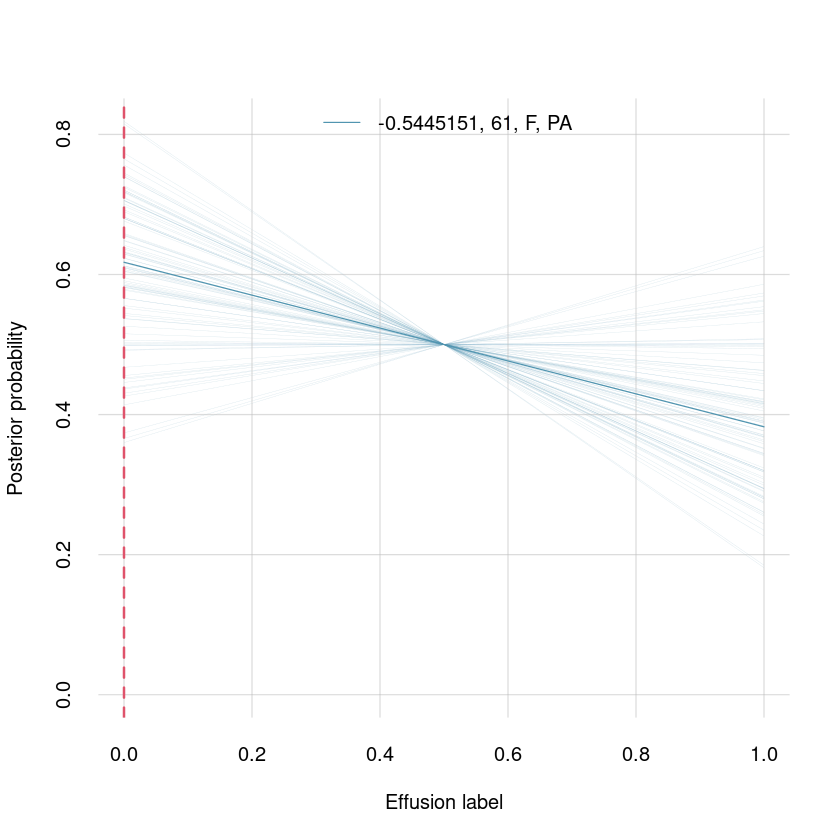

In [1]:
#=======================================================================================================================
# 📦 Load Inferno Package
#=======================================================================================================================
library("inferno")
library("jsonlite")

#=======================================================================================================================
# 📁 Setup Paths and Load Model
#=======================================================================================================================
relative_path <- "../data/inferno"
input_file    <- file.path(relative_path, "calibration_test.csv")
inferno_dir   <- file.path(relative_path, "effusion")
inferno_model <- readRDS(file.path(inferno_dir, "learnt.rds"))

#=======================================================================================================================
# 📊 Load Data and Select Row
#=======================================================================================================================
alldata <- read.csv(
  input_file,
  na.strings = "",
  stringsAsFactors = FALSE,
  tryLogical = FALSE
)
r <- 1050
row_data <- alldata[r, ]
print(row_data)

#=======================================================================================================================
# 🔍 Prepare Input and Predict
#=======================================================================================================================
input_features <- row_data[, c("LOGIT_EFFUSION", "AGE", "GENDER", "VP")]
target_frame <- data.frame(LABEL_EFFUSION = 0:1)
uncertainty_bounds <- c(0.055, 0.25, 0.75, 0.945)

result_probs <- Pr(
  Y = target_frame,
  X = input_features,
  learnt = inferno_model,
  parallel = 7,
  quantile = uncertainty_bounds
)

#=======================================================================================================================
# 💾 Save Result to JSON (Including True Label)
#=======================================================================================================================
output_path <- file.path(relative_path, "result_probs.json")
export_data <- list(
  values     = result_probs$values,
  samples    = result_probs$samples,
  quantiles  = result_probs$quantiles,
  Y          = result_probs$Y,
  X          = result_probs$X,
  lowertail  = result_probs$lowertail,
  true_label = row_data$LABEL_EFFUSION
)
write(
  toJSON(export_data, pretty = TRUE, auto_unbox = TRUE),
  file = output_path
)

#=======================================================================================================================
# 📈 Plot Prediction
#=======================================================================================================================
plot(
  result_probs,
  variability = "samples",
  col = adjustcolor("#5195b0", alpha.f = 1),
  lwd = 1,
  grid = TRUE,
  legend = TRUE,
  xlab = "Effusion label",
  ylab = "Posterior probability"
)
abline(v = row_data[, "LABEL_EFFUSION"], lty = 2, lwd = 2, col = 2)